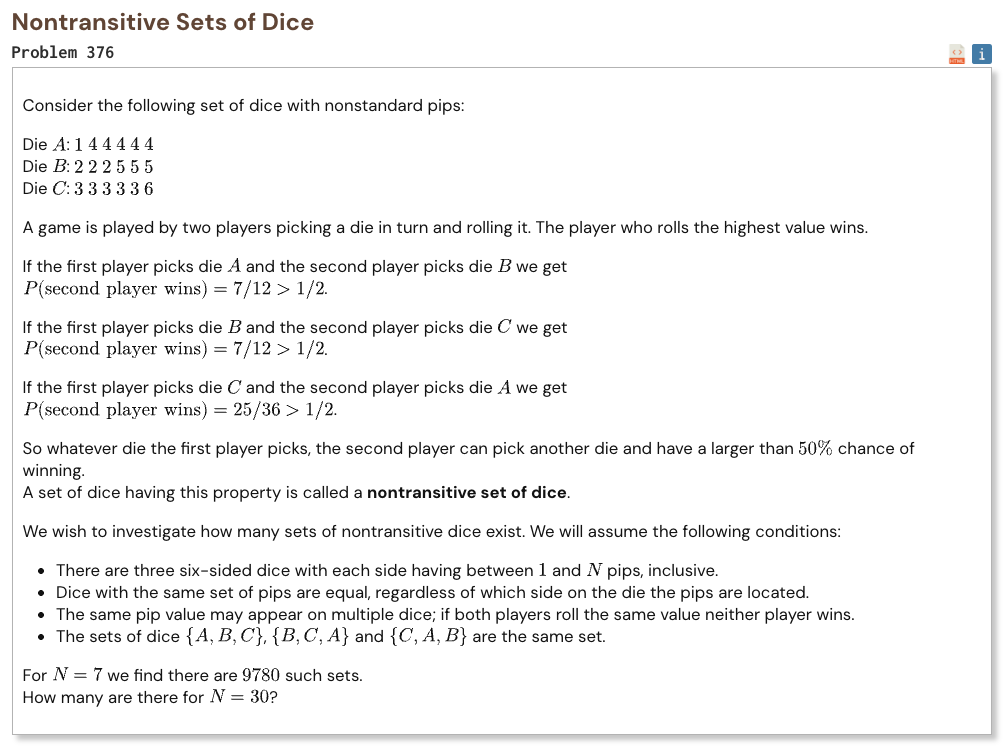

## Initial approach

* generate every distinct six-sided die as a sorted multiset of face values
* compare every pair of dice once and record which die wins more often
* build a directed graph where an edge means one die beats another with probability greater than one half
* look for directed 3-cycles because they correspond exactly to nontransitive sets
* divide out rotational duplicates so each unordered set is counted once
* use itertools to generate multisets efficiently
* verify the small example before solving the full limit

In [1]:
from itertools import combinations_with_replacement

def generate_dice(limit):
    return list(combinations_with_replacement(range(1, limit + 1), 6))

def wins(a, b):
    score = 0

    for x in a:
        for y in b:
            if x > y:
                score += 1
            elif x < y:
                score -= 1

    return score

def solve(limit):
    dice = generate_dice(limit)
    n = len(dice)

    beats = [set() for _ in range(n)]

    for i in range(n):
        for j in range(i + 1, n):
            score = wins(dice[i], dice[j])

            if score > 0:
                beats[i].add(j)
            elif score < 0:
                beats[j].add(i)

    total = 0

    for i in range(n):
        for j in beats[i]:
            if j <= i:
                continue

            common = beats[j] & beats[i]

            for k in common:
                if k > j and i in beats[k]:
                    total += 1

    return total

assert solve(3) == 0

In [2]:
%%time
result = solve(7)
print("Result:", result)

Result: 0
CPU times: user 1.37 s, sys: 15 ms, total: 1.39 s
Wall time: 1.39 s
